# Arsenic: Bangladesh Water Supply
Arsenic is a naturally occuring element in the groundwater of Bangladesh. Much of the groundwater is used or drinking by the rural population, so arsenic poisoning is a serious health issue. 

The dataset is water samples and chemical measurements from the Bangladesh water table. The chemical tests include Arsenic, Chlorine, and Cobalt. These chemicals are known to cause posionous effects in humans. The measurement units are parts per billion (ppb).

The US Environmental Protection Agency (EPA) sets an arsenic maximum contaminant level (MCL) at 10 ppb.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
water_data = pd.read_csv("../Data/Bangladesh.csv")

water_data.describe()

,Arsenic,Chlorine,Cobalt
count,271.000000,269.000000,270.000000
mean,125.319926,78.084015,0.503778
std,297.975491,210.019193,0.377409
min,0.500000,1.000000,0.050000
25%,6.000000,5.000000,0.282500
50%,22.000000,14.200000,0.410000
75%,109.000000,55.500000,0.630000
max,2400.000000,1550.000000,3.180000


The sample mean, $\bar{x}$, is 125.32 ppb. The sample standard deviation, $\bar{\sigma^2}$, is 297.98 ppb.

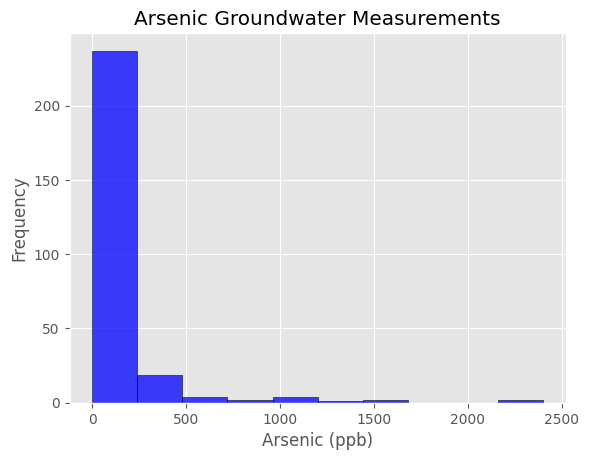

In [3]:
# Plot the histogram of arsenic measurements of wells
plt.hist(water_data["Arsenic"], bins=10, color="blue", alpha=0.75, edgecolor="black")
plt.title("Arsenic Groundwater Measurements")
plt.xlabel("Arsenic (ppb)")
plt.ylabel("Frequency")
plt.show()

To further quantify the behavior of the sample mean as an estimate, we will use bootstrap sampling.

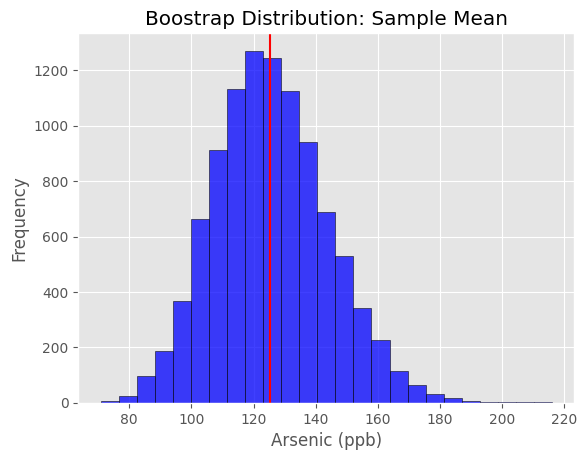

In [4]:
B = 10_000

arsenic_means = []
for b in range(B):
    sample = water_data["Arsenic"].sample(n=len(water_data["Arsenic"]), replace=True)
    arsenic_means.append(sample.mean())

# Bootstrap distribution of sample means
plt.hist(arsenic_means, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(water_data["Arsenic"].mean(), color="red")
plt.title("Boostrap Distribution: Sample Mean")
plt.xlabel("Arsenic (ppb)")
plt.ylabel("Frequency")
plt.show()

In [5]:
# Obtain the bootstrap mean, standard error, and bias
bs_mean     = np.mean(arsenic_means)
bs_sd_error = np.std(arsenic_means)
bs_bias     = np.abs(bs_mean - water_data["Arsenic"].mean())

print(f"Bootstrap Mean:           {bs_mean:.4f}")
print(f"Bootstrap Standard Error: {bs_sd_error:.4f}")
print(f"Bootstrap Bias (mean):    {bs_bias:.4f}")

Bootstrap Mean:           125.6632
Bootstrap Standard Error: 18.1946
Bootstrap Bias (mean):    0.3433


Lower: 90.0019
Upper: 161.3246


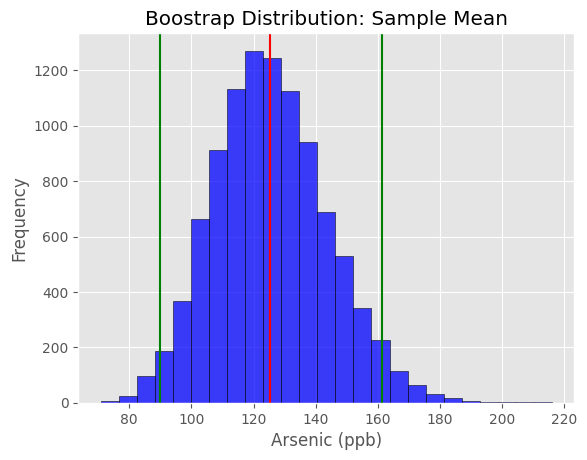

In [6]:
# Compute points 1.96 standard errors from the mean (CLT)
lower = bs_mean - 1.96 * bs_sd_error
upper = bs_mean + 1.96 * bs_sd_error

print(f"Lower: {lower:.4f}")
print(f"Upper: {upper:.4f}")

# Bootstrap distribution of sample means with cutoffs
plt.hist(arsenic_means, bins=25, color="blue", alpha=0.75, edgecolor="black")
plt.axvline(water_data["Arsenic"].mean(), color="red")
plt.axvline(lower, color="green")
plt.axvline(upper, color="green")
plt.title("Boostrap Distribution: Sample Mean")
plt.xlabel("Arsenic (ppb)")
plt.ylabel("Frequency")
plt.show()

In [7]:
# Compute tail probabilities
p_upper = np.sum(arsenic_means > upper) / len(arsenic_means)
p_lower = np.sum(arsenic_means < lower) / len(arsenic_means)

print(f"P(X_bar > 1.96 SE from mean): {p_upper:.4f}")
print(f"P(X_bar < 1.96 SE from mean): {p_lower:.4f}")

P(X_bar > 1.96 SE from mean): 0.0316
P(X_bar < 1.96 SE from mean): 0.0174


In [9]:
# 95% boostrap confidence interval
interval = np.percentile(arsenic_means, q=[2.5, 97.5])

print(interval)

[ 92.55129151 163.33035055]


We have 95% confidence that the true mean of the arsenic levels in the groundwater in Bangladesh is between 92.6 and 163.3 ppb.